In [5]:
import kagglehub
import pandas as pd
from fastai.tabular.all import *

In [6]:
path = kagglehub.dataset_download(
    "aiexplorer77/gaming-vs-academic-performance",
    output_dir='./data'
)
path = Path(path)
print("Path to dataset files:", path)

Path to dataset files: data


In [7]:
base_path = Path('.')
df = pd.read_csv(path/'Gaming_Academic_Performance.csv')

In [8]:
test_df = df.sample(frac=0.1, random_state=42)
main_df = df.drop(test_df.index)

In [9]:
main_df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='str')

In [25]:
dls = TabularDataLoaders.from_df(
    main_df,
    path=base_path,
    y_names='grades',
    # Adding more categories for better context
    cat_names=['gaming_genre', 'gender', 'device_usage', 'stress_level'], 
    # Adding the 'heavy hitters' to continuous variables
    cont_names=[
        'age', 'gaming_hours', 'sleep_hours', 
        'study_hours', 'attendance', 'social_activity', 'addiction_score', 'reaction_time_ms'
    ],
    procs=[Categorify, FillMissing, Normalize]
)

In [26]:
dls.show_batch()

,gaming_genre,gender,device_usage,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,grades
0,FPS,Female,5.56,Medium,24.0,0.41,5.41,1.87,68.110000,1.25,5.600000,303.649992,56.509998
1,Casual,Male,9.45,Low,18.0,7.82,5.62,6.93,71.059998,3.97,17.620001,225.509995,34.919998
2,FPS,Female,5.34,Medium,17.0,1.02,7.28,1.42,69.639999,1.98,3.780000,307.559996,65.803612
3,Casual,Male,4.58,Medium,23.0,1.50,4.63,4.86,85.669998,0.33,6.080000,303.480011,67.790001
4,Casual,Female,8.61,High,19.0,3.28,4.49,8.35,72.010002,1.61,10.020000,282.839996,83.900002
5,RPG,Male,8.88,High,19.0,5.38,5.67,9.45,68.320000,0.20,12.490000,269.010010,75.073555
6,FPS,Female,8.9,Medium,22.0,4.50,7.43,1.96,63.729999,4.66,11.120000,273.589996,42.400002
7,FPS,Female,9.32,Medium,20.0,4.12,7.97,1.81,76.910004,0.91,8.670000,247.979996,48.049999
8,RPG,Female,8.68,Low,19.0,5.72,8.32,3.90,90.720001,2.11,12.990000,265.540009,62.490002
9,FPS,Female,12.01,Low,16.0,7.80,5.01,5.33,67.830002,1.55,19.459999,223.070009,28.280001


<div></div>

Minimum loss divided by 10: 0.0020892962347716093


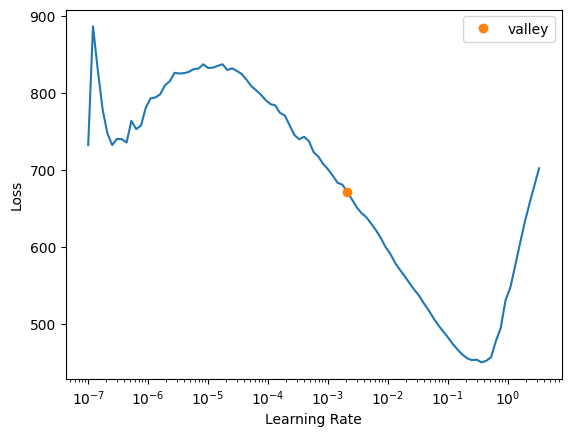

In [27]:
# Create the learner with the grade limits
learn = tabular_learner(
    dls, 
    layers=[200,100],
    metrics=rmse, 
    y_range=(0, 100)
)
suggestions = learn.lr_find()
print(f"Minimum loss divided by 10: {suggestions.valley}")

In [28]:
learn.fit_one_cycle(12, slice(1.7e-3, 1e-2))

epoch,train_loss,valid_loss,_rmse,time
0,212.400391,105.651993,10.278717,00:01
1,84.119484,55.641148,7.459301,00:01
2,57.185078,50.659771,7.117568,00:01
3,48.008129,58.754211,7.665130,00:01
4,36.856113,54.384377,7.374577,00:01
5,34.267326,47.541752,6.895052,00:01
6,31.392519,53.507801,7.314903,00:01
7,28.630711,50.155437,7.082050,00:01
8,23.819675,49.493931,7.035192,00:01
9,21.528315,52.230122,7.227041,00:01


In [20]:
learn.fine_tune(12, slice(1.7e-3, 1e-2))

TypeError: unsupported operand type(s) for /: 'slice' and 'int'

In [17]:
learn.show_results()

,gaming_genre,gender,device_usage,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,grades,grades_pred
0,2.0,2.0,381.0,3.0,0.783349,-0.287279,-0.960995,0.429913,1.583610,1.114350,-0.473055,0.070218,76.419998,79.137215
1,3.0,2.0,891.0,2.0,0.783349,1.046064,1.045764,-0.511792,-1.510780,-0.112909,1.072324,-0.223427,33.849998,40.273464
2,3.0,1.0,434.0,3.0,-1.533713,-1.330576,-0.027294,-1.731376,-0.721183,0.760733,-0.715390,1.724563,56.470001,51.738358
3,3.0,2.0,566.0,3.0,0.397172,-0.490743,-1.114289,0.526399,-1.095658,-0.293185,-0.627990,0.442122,78.169998,71.603394
4,3.0,2.0,516.0,3.0,1.555703,-0.096801,0.119032,1.599325,1.167623,0.060432,-0.129417,-0.486108,99.300003,94.633591
5,3.0,2.0,697.0,3.0,0.010995,0.028741,-1.483588,0.368162,1.639824,-0.182246,-0.467096,0.251576,63.650002,68.889160
6,2.0,2.0,403.0,3.0,0.783349,-0.148750,-0.048198,-0.820547,1.230756,-1.187628,0.132781,-0.996158,64.489998,57.876091
7,1.0,2.0,726.0,3.0,-0.761359,0.375063,1.282673,-1.032817,1.308591,-1.395638,-0.276407,-0.461609,52.529999,62.017639
8,1.0,2.0,1012.0,2.0,-1.533713,1.552561,-1.058546,-1.407183,-1.049822,0.400182,1.751655,-1.038350,7.020000,11.746448


In [18]:
test_df = pd.read_csv('./data/test.csv')
dl = learn.dls.test_dl(test_df)
preds, _ = learn.get_preds(dl=dl)

In [19]:
# Convert predictions to a simple list of numbers
preds_list = preds.flatten().tolist() 
test_df['actual'] = test_df['grades'] # Replace with your real column name
test_df['predicted'] = preds_list

# Look at the first 10 rows
print(test_df[['actual', 'predicted']].head(100))

        actual  predicted
0    57.286971  46.715168
1    76.020000  73.370613
2    42.680000  51.538551
3    17.310000  18.364901
4   106.774359  89.104912
..         ...        ...
95   44.964754  30.042807
96   49.920000  53.587967
97   42.490000  43.660053
98   85.770000  86.998001
99   73.530000  64.805984

[100 rows x 2 columns]
